In [1]:
# Importing necessary packages and libraries

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import datetime
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_absolute_error, mean_squared_error
from tabulate import tabulate


In [3]:
#Importing dataset

Crops=pd.read_csv("Crop_recommendation.csv")
Crops.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# To check data type and non-null values

Crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
# To identify the duplicate rows in DataFrame

Crops.duplicated().sum()

np.int64(0)

**Pre-processing**

In [6]:
# Check number of missing values per column

missing_values_per_column = Crops.isna().sum()
missing_values_per_column

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
# A summary statistics to understand the distribution and central tendency of the data.

Crops.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


**Exploring data**

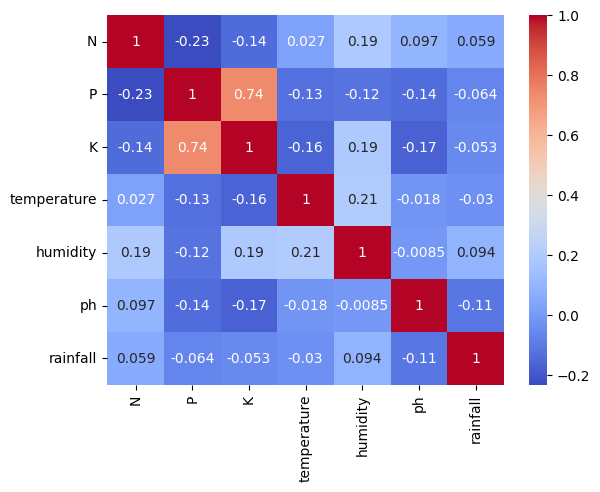

In [10]:
# To interpret the correlation coefficients between different pairs of variables.

df_numeric = Crops.select_dtypes(include=[np.number])
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cbar=True, cmap='coolwarm')
plt.show()


In [8]:
# To count the occurrences of each unique value in the column

Crops['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

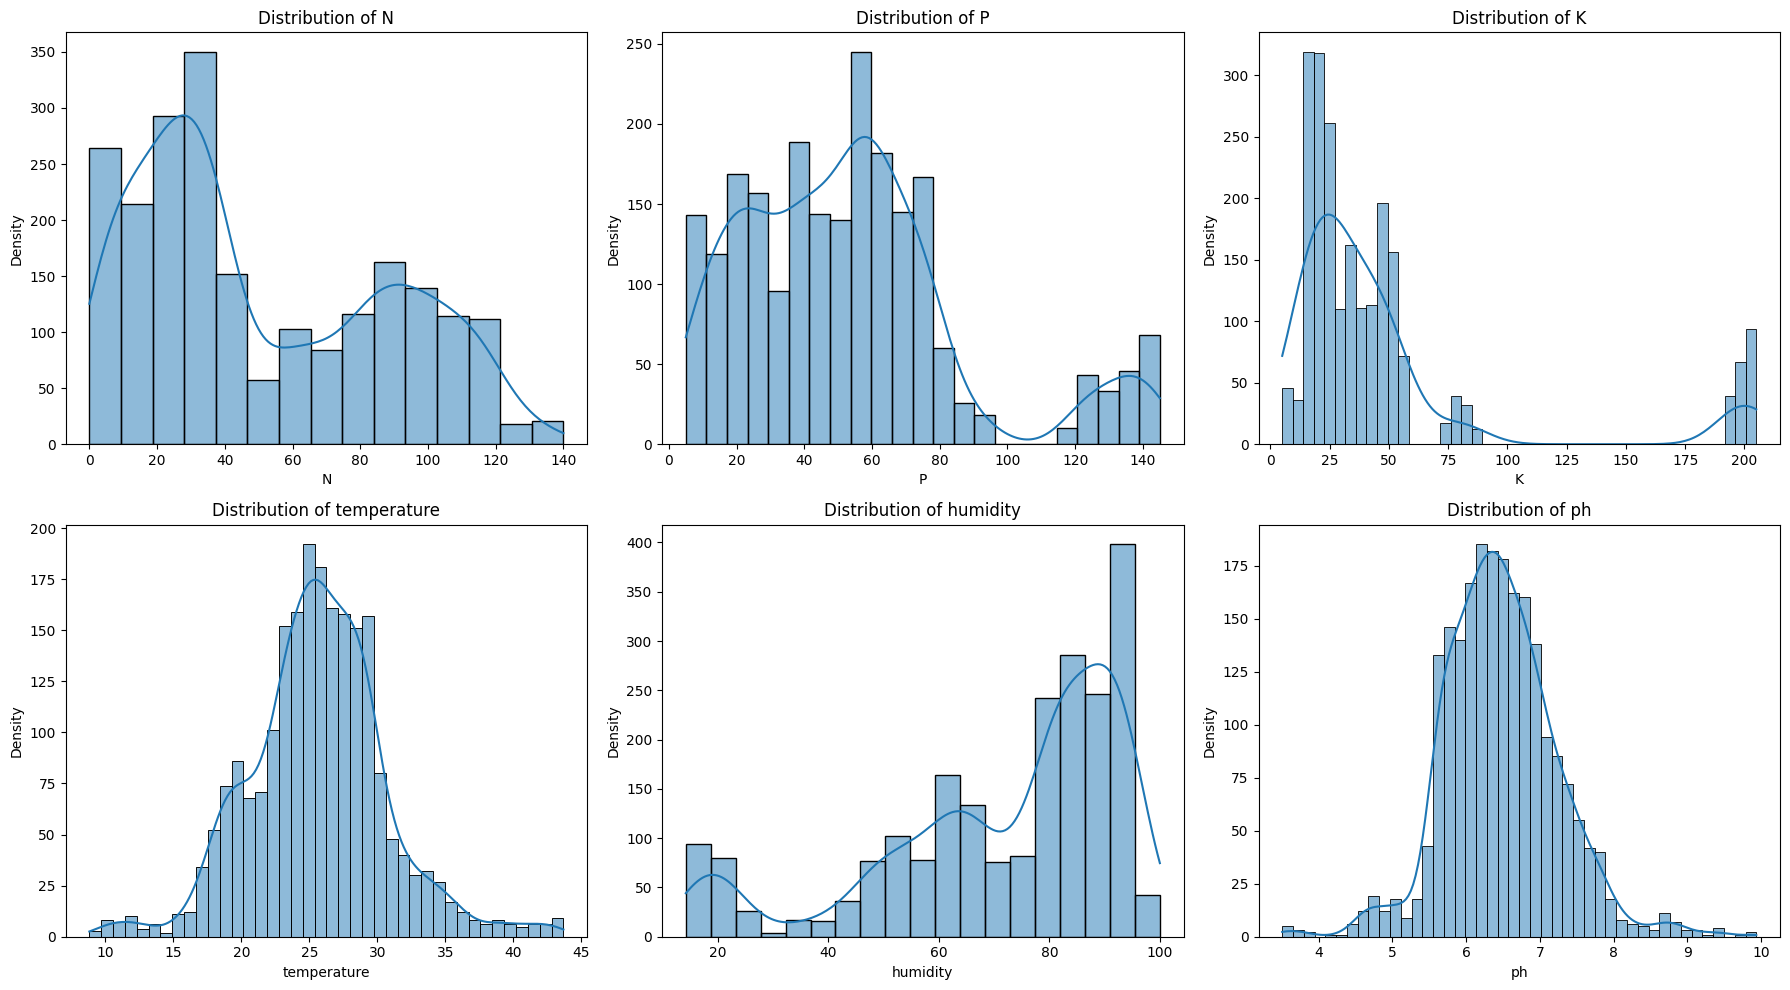

In [9]:
# To visualize the distribution of a numerical variable in dataset for exploratory analysis, data preprocessing, model selection.

import seaborn as sns
import matplotlib.pyplot as plt

columns_to_plot = Crops.columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, column in enumerate(columns_to_plot):
    row = i // 3
    col = i % 3
    sns.histplot(Crops[column], ax=axes[row, col], kde=True)
    axes[row, col].set_title(f"Distribution of {column}")
    axes[row, col].set_xlabel(column)
    axes[row, col].set_ylabel("Density")
plt.tight_layout()
plt.show()


Encoding

In [10]:
# Crop names are being encoded into numerical labels, where each label represents a specific crop category.

crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}
Crops['crop_num']=Crops['label'].map(crop_dict)

In [11]:
Crops['crop_num'].value_counts()

crop_num
1     100
2     100
21    100
20    100
19    100
18    100
17    100
16    100
15    100
14    100
13    100
12    100
11    100
10    100
9     100
8     100
7     100
6     100
5     100
4     100
3     100
22    100
Name: count, dtype: int64

In [12]:
Crops.head()

,N,P,K,temperature,humidity,ph,rainfall,label,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


In [13]:
Crops.drop(['label'],axis=1,inplace=True)

In [14]:
Crops.head()

,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [15]:
# Train - test split data

features = Crops.iloc[:, :-1].values
labels = Crops.iloc[:, -1].values

In [16]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [17]:
# Train Models

from tabulate import tabulate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# create instances of all models
models = {
    'Logistic Regression': LogisticRegression(solver='sag', max_iter=1000),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier()
}

# Fit models and calculate accuracy scores
accuracy_scores = []
for name, md in models.items():
    # Fit the model
    md.fit(features_train, labels_train)

    # Predict on test data
    y_pred = md.predict(features_test)

    # Calculate accuracy score
    accuracy = accuracy_score(labels_test, y_pred)

    # Append accuracy score to list
    accuracy_scores.append([name, accuracy])

# Sort accuracy scores in descending order
sorted_accuracy_scores = sorted(accuracy_scores, key=lambda x: x[1], reverse=True)

# Print accuracy scores in table format
print(tabulate(sorted_accuracy_scores, headers=['Model', 'Accuracy'], tablefmt='grid'))


C:\Users\best\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\best\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


+------------------------+------------+
| Model                  |   Accuracy |
+========================+============+
| Random Forest          |   0.993182 |
+------------------------+------------+
| Decision Tree          |   0.984091 |
+------------------------+------------+
| K-Nearest Neighbors    |   0.970455 |
+------------------------+------------+
| Support Vector Machine |   0.961364 |
+------------------------+------------+
| Logistic Regression    |   0.943182 |
+------------------------+------------+
| AdaBoost               |   0.140909 |
+------------------------+------------+


In [ ]:
# Test models

# Take user input for parameters
N = float(input("Enter Nitrogen level: "))
P = float(input("Enter Phosphorous level: "))
k = float(input("Enter Potassium level: "))
temperature = float(input("Enter temperature: "))
humidity = float(input("Enter humidity: "))
ph = float(input("Enter pH value: "))
rainfall = float(input("Enter rainfall: "))

# Initialize classifiers
classifiers = {
    "RFC": RandomForestClassifier(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    'LR': LogisticRegression(),
    'DT': DecisionTreeClassifier(),
    'AB': AdaBoostClassifier()
}

# Train classifiers
for clf_name, clf in classifiers.items():
    clf.fit(features_train, labels_train)

# Predictions for each classifier
predictions = {}
for clf_name, clf in classifiers.items():
    predictions[clf_name] = clf.predict(np.array([[N, P, k, temperature, humidity, ph, rainfall]]))


table_data = []

for clf_name, prediction in predictions.items():
    prediction_single = prediction[0] if isinstance(prediction, np.ndarray) else prediction
    crop_recommendation = crop_dict.get(prediction_single, "No recommendation")
    table_data.append([clf_name, crop_recommendation])

print(tabulate(table_data, headers=["Classifier", "Crop Recommendation"], tablefmt="grid"))


**Evaluation Metrics**

In [ ]:
def evaluate_performance(model, features_train, labels_train, features_test, labels_test):

    model.fit(features_train, labels_train)

    # Predictions
    train_pred = model.predict(features_train)
    test_pred = model.predict(features_test)

    # Compute performance metrics
    train_accuracy = accuracy_score(labels_train, train_pred)
    test_accuracy = accuracy_score(labels_test, test_pred)
    train_precision = precision_score(labels_train, train_pred, average='weighted')
    test_precision = precision_score(labels_test, test_pred, average='weighted')
    train_recall = recall_score(labels_train, train_pred, average='weighted')
    test_recall = recall_score(labels_test, test_pred, average='weighted')
    train_f1 = f1_score(labels_train, train_pred, average='weighted')
    test_f1 = f1_score(labels_test, test_pred, average='weighted')

    results_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
        'Training': [train_accuracy, train_precision, train_recall, train_f1],
        'Testing': [test_accuracy, test_precision, test_recall, test_f1]
    })

    return results_df

# Train and evaluate each classifier
results = []
for clf_name, clf in classifiers.items():
    clf.fit(features_train, labels_train)
    results_df = evaluate_performance(clf, features_train, labels_train, features_test, labels_test)
    results.append((clf_name, results_df))

for clf_name, results_df in results:
    print(f"\nClassifier: {clf_name}")
    print(tabulate(results_df, headers='keys', tablefmt='fancy_grid'))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Classifier: RFC
╒════╤═══════════╤════════════╤═══════════╕
│    │ Metric    │   Training │   Testing │
╞════╪═══════════╪════════════╪═══════════╡
│  0 │ Accuracy  │          1 │  0.993182 │
├────┼───────────┼────────────┼───────────┤
│  1 │ Precision │          1 │  0.993735 │
├────┼───────────┼────────────┼───────────┤
│  2 │ Recall    │          1 │  0.993182 │
├────┼───────────┼────────────┼───────────┤
│  3 │ F1-score  │          1 │  0.993175 │
╘════╧═══════════╧════════════╧═══════════╛

Classifier: SVC
╒════╤═══════════╤════════════╤═══════════╕
│    │ Metric    │   Training │   Testing │
╞════╪═══════════╪════════════╪═══════════╡
│  0 │ Accuracy  │   0.98125  │  0.961364 │
├────┼───────────┼────────────┼───────────┤
│  1 │ Precision │   0.983767 │  0.967269 │
├────┼───────────┼────────────┼───────────┤
│  2 │ Recall    │   0.98125  │  0.961364 │
├────┼───────────┼────────────┼───────────┤
│  3 │ F1-score  │   0.981166 │  0.961243 │
╘════╧═══════════╧════════════╧═══════════

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Bias and Variance**

In [ ]:
# Define a function to calculate bias and variance
def calculate_bias_variance(classifier, features, labels, cv=5, scoring='accuracy'):
    # Perform cross-validation to estimate bias and variance
    cv_scores = cross_val_score(classifier, features, labels, cv=cv, scoring=scoring)

    # Calculate mean and standard deviation of cross-validation scores
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)

    # Calculate bias and variance
    bias = 1 - mean_cv_score
    variance = std_cv_score

    return bias, variance

# Initialize classifiers
classifiers = {
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(solver='sag', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Calculate bias and variance for each classifier
results = []
for classifier_name, classifier in classifiers.items():
    bias, variance = calculate_bias_variance(classifier, features, labels)
    results.append({
        'Classifier': classifier_name,
        'Bias': bias,
        'Variance': variance
    })


results_df = pd.DataFrame(results)
print(tabulate(results_df, headers='keys', tablefmt='fancy_grid'))


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


╒════╤═════════════════════╤════════════╤════════════╕
│    │ Classifier          │       Bias │   Variance │
╞════╪═════════════════════╪════════════╪════════════╡
│  0 │ Random Forest       │ 0.00590909 │ 0.00231774 │
├────┼─────────────────────┼────────────┼────────────┤
│  1 │ SVC                 │ 0.0218182  │ 0.00396264 │
├────┼─────────────────────┼────────────┼────────────┤
│  2 │ KNN                 │ 0.0213636  │ 0.00308288 │
├────┼─────────────────────┼────────────┼────────────┤
│  3 │ Logistic Regression │ 0.0359091  │ 0.00440698 │
├────┼─────────────────────┼────────────┼────────────┤
│  4 │ Decision Tree       │ 0.0136364  │ 0.00248965 │
├────┼─────────────────────┼────────────┼────────────┤
│  5 │ AdaBoost            │ 0.790909   │ 0.0222681  │
╘════╧═════════════════════╧════════════╧════════════╛
